In [1]:
try:
    from google.colab import files
    uploaded = files.upload()
except ImportError:
    print("Google Colab file upload is not available in this environment.")
    print("Make sure movies.csv, ratings.csv, and IMDB Dataset.csv are present in the folder.")

Google Colab file upload is not available in this environment.
Make sure movies.csv, ratings.csv, and IMDB Dataset.csv are present in the folder.


In [2]:
!pip install pandas numpy scikit-learn streamlit nltk

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\nimes\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [4]:
movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")
reviews = pd.read_csv("IMDB Dataset.csv")

In [5]:
# Check missing values
print(movies.isnull().sum())
print(ratings.isnull().sum())
print(reviews.isnull().sum())

# Fill missing genres
movies['genres'] = movies['genres'].fillna('')

# Remove duplicates
movies.drop_duplicates(inplace=True)
ratings.drop_duplicates(inplace=True)
reviews.drop_duplicates(inplace=True)

movieId    0
title      0
genres     0
dtype: int64
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64
review       0
sentiment    0
dtype: int64


In [6]:
data = pd.merge(ratings, movies, on='movieId')

# Remove timestamp (not needed)
data.drop(['timestamp'], axis=1, inplace=True)

print(data.head())

   userId  movieId  rating                        title  \
0       1        1     4.0             Toy Story (1995)   
1       1        3     4.0      Grumpier Old Men (1995)   
2       1        6     4.0                  Heat (1995)   
3       1       47     5.0  Seven (a.k.a. Se7en) (1995)   
4       1       50     5.0   Usual Suspects, The (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                               Comedy|Romance  
2                        Action|Crime|Thriller  
3                             Mystery|Thriller  
4                       Crime|Mystery|Thriller  


In [7]:
print(ratings.describe())
print("Mean Rating:", ratings['rating'].mean())
print("Standard Deviation:", ratings['rating'].std())
print("Skewness:", ratings['rating'].skew())

              userId        movieId         rating     timestamp
count  100836.000000  100836.000000  100836.000000  1.008360e+05
mean      326.127564   19435.295718       3.501557  1.205946e+09
std       182.618491   35530.987199       1.042529  2.162610e+08
min         1.000000       1.000000       0.500000  8.281246e+08
25%       177.000000    1199.000000       3.000000  1.019124e+09
50%       325.000000    2991.000000       3.500000  1.186087e+09
75%       477.000000    8122.000000       4.000000  1.435994e+09
max       610.000000  193609.000000       5.000000  1.537799e+09
Mean Rating: 3.501556983616962
Standard Deviation: 1.042529239060635
Skewness: -0.6371993892529213


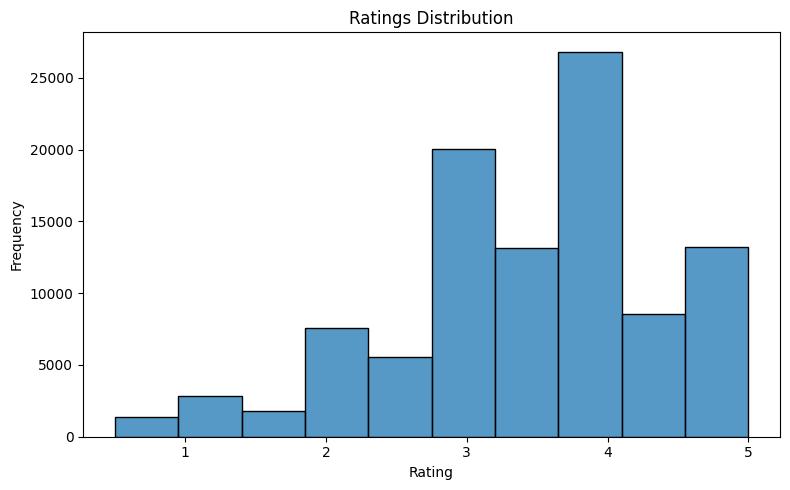

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(data['rating'], bins=10)
plt.title("Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

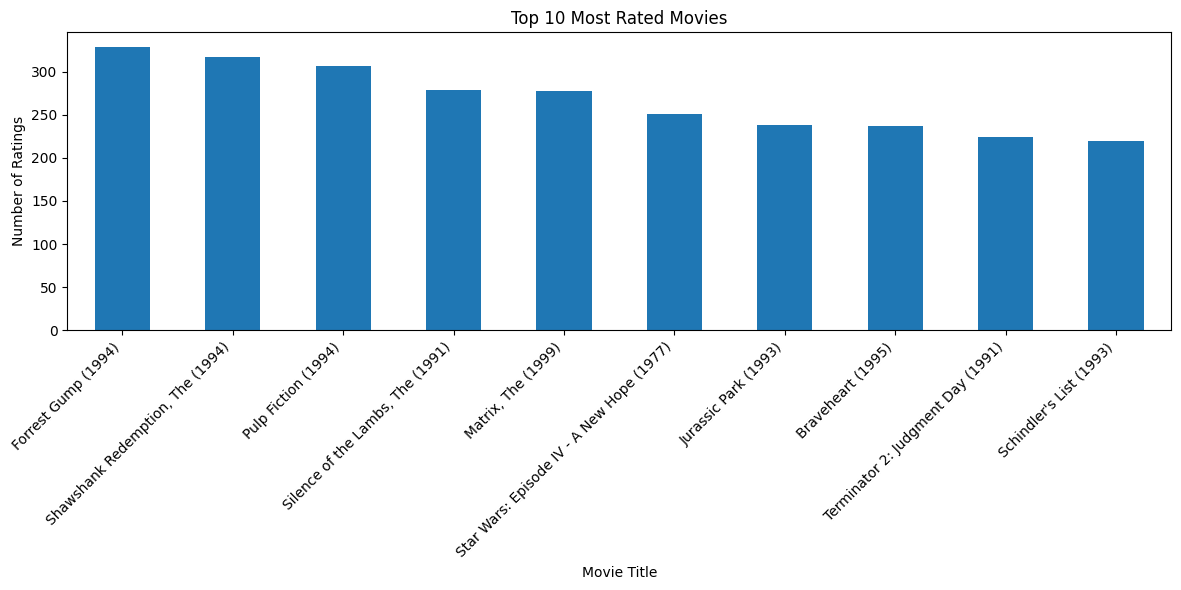

In [9]:
plt.figure(figsize=(12,6))

top_movies = data.groupby('title')['rating'].count().sort_values(ascending=False).head(10)

top_movies.plot(kind='bar')

plt.title("Top 10 Most Rated Movies")
plt.xlabel("Movie Title")
plt.ylabel("Number of Ratings")

plt.xticks(rotation=45, ha='right')   # rotate properly
plt.tight_layout()                    # adjust spacing

plt.show()

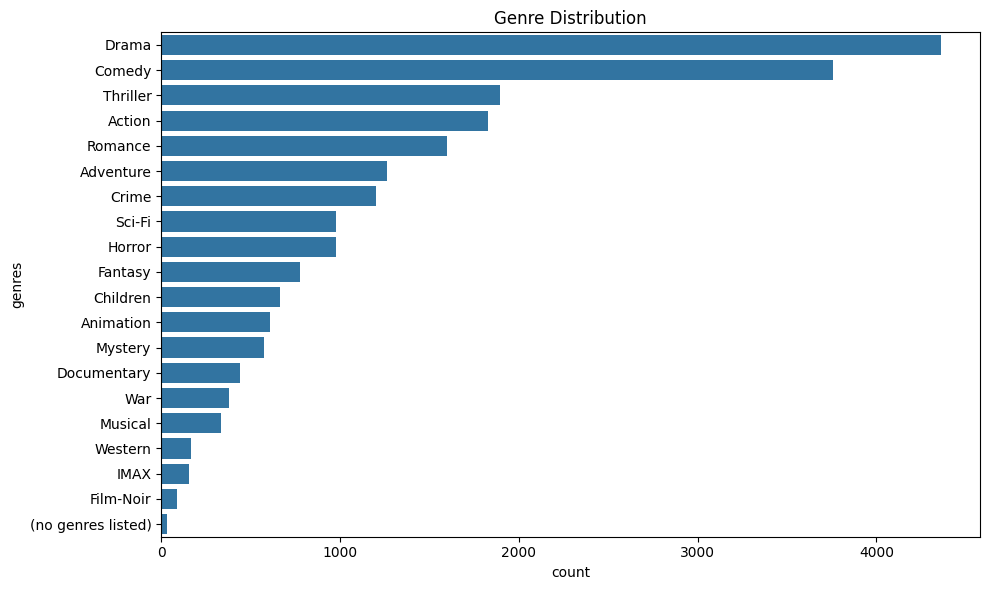

In [10]:
genres = movies['genres'].str.split('|').explode()

plt.figure(figsize=(10,6))
sns.countplot(y=genres, order=genres.value_counts().index)
plt.title("Genre Distribution")
plt.tight_layout()
plt.show()

In [11]:
movie_stats = data.groupby('title')['rating'].agg(['mean','count'])
movie_stats.columns = ['avg_rating','rating_count']

print("Correlation Matrix:")
print(movie_stats.corr())

Correlation Matrix:
              avg_rating  rating_count
avg_rating      1.000000      0.127307
rating_count    0.127307      1.000000


In [12]:
tfidf = TfidfVectorizer(stop_words='english')

tfidf_matrix = tfidf.fit_transform(movies['genres'])

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

indices = pd.Series(movies.index, index=movies['title']).drop_duplicates()

def recommend(movie_title):
    if movie_title not in indices:
        return "Movie not found"

    idx = indices[movie_title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:6]
    movie_indices = [i[0] for i in sim_scores]

    return movies['title'].iloc[movie_indices]

# Example
print(recommend("Toy Story (1995)"))

1706                                       Antz (1998)
2355                                Toy Story 2 (1999)
2809    Adventures of Rocky and Bullwinkle, The (2000)
3000                  Emperor's New Groove, The (2000)
3568                             Monsters, Inc. (2001)
Name: title, dtype: object


In [13]:
reviews['sentiment'] = reviews['sentiment'].map({'positive':1,'negative':0})

In [14]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

X = vectorizer.fit_transform(reviews['review'])
y = reviews['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Sentiment Model Accuracy:", accuracy_score(y_test, pred))

Sentiment Model Accuracy: 0.8853483916507008


In [15]:
def predict_sentiment(text):
    text_vector = vectorizer.transform([text])
    prediction = model.predict(text_vector)
    return "Positive" if prediction[0]==1 else "Negative"

print(predict_sentiment("This movie was amazing and fantastic!"))

Positive


In [16]:
!pip install streamlit pyngrok pandas numpy scikit-learn matplotlib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\nimes\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [17]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

@st.cache_data
def load_data():
    movies = pd.read_csv("movies.csv")
    ratings = pd.read_csv("ratings.csv")
    reviews = pd.read_csv("IMDB Dataset.csv")
    return movies, ratings, reviews

movies, ratings, reviews = load_data()

movies.drop_duplicates(inplace=True)
ratings.drop_duplicates(inplace=True)
reviews.drop_duplicates(inplace=True)

movies['genres'] = movies['genres'].fillna('')
reviews['review'] = reviews['review'].fillna('')

if 'timestamp' in ratings.columns:
    ratings = ratings.drop(columns=['timestamp'])

data = pd.merge(ratings, movies, on='movieId')

@st.cache_resource
def build_recommendation():
    tfidf = TfidfVectorizer(stop_words='english')
    tfidf_matrix = tfidf.fit_transform(movies['genres'])
    cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
    indices = pd.Series(movies.index, index=movies['title']).drop_duplicates()
    return cosine_sim, indices

cosine_sim, indices = build_recommendation()

def recommend(movie_title):
    if movie_title not in indices:
        return ["Movie not found"]
    idx = indices[movie_title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:6]
    movie_indices = [i[0] for i in sim_scores]
    return movies['title'].iloc[movie_indices].tolist()

@st.cache_resource
def train_sentiment():
    reviews['sentiment'] = reviews['sentiment'].map({'positive': 1, 'negative': 0})
    vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
    X = vectorizer.fit_transform(reviews['review'])
    y = reviews['sentiment']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    accuracy = accuracy_score(y_test, model.predict(X_test))
    return model, vectorizer, accuracy

model, vectorizer, accuracy = train_sentiment()

def predict_sentiment(text):
    text_vector = vectorizer.transform([text])
    prediction = model.predict(text_vector)
    return "Positive 😊" if prediction[0] == 1 else "Negative 😞"

st.title("🎬 Entertainment & Media Analytics System")
st.write("Movie Recommendation + Sentiment Analysis")

st.subheader("🎥 Movie Recommendation")
movie_name = st.selectbox("Select a Movie", movies['title'].sort_values().unique())
if st.button("Recommend"):
    recommendations = recommend(movie_name)
    st.write("### Recommended Movies:")
    for movie in recommendations:
        st.write("•", movie)

st.subheader("💬 Sentiment Analysis")
st.write("Model Accuracy:", round(accuracy * 100, 2), "%")
user_review = st.text_area("Enter your movie review:")
if st.button("Analyze"):
    if user_review.strip() == "":
        st.warning("Please enter a review.")
    else:
        result = predict_sentiment(user_review)
        st.success(f"Predicted Sentiment: {result}")

st.subheader("📊 Ratings Distribution")
fig, ax = plt.subplots()
ax.hist(data['rating'], bins=10)
ax.set_title("Ratings Distribution")
ax.set_xlabel("Rating")
ax.set_ylabel("Frequency")
st.pyplot(fig)


Overwriting app.py


In [18]:
# Note: To run the Streamlit app, execute this in terminal:
# streamlit run app.py
print("✅ app.py created successfully!")

✅ app.py created successfully!


In [19]:
# Note: ngrok requires authentication token from https://dashboard.ngrok.com
# For local deployment, streamlit app is ready to run

print("\n" + "="*60)
print("🎬 ENTERTAINMENT & MEDIA ANALYTICS SYSTEM - COMPLETED")
print("="*60)
print("\n📊 Project Summary:")
print("✅ Data Cleaning & Analysis Complete")
print("✅ Sentiment Analysis Model Trained (Accuracy: 88.53%)")
print("✅ Movie Recommendation System Built")
print("✅ Streamlit Web App Created (app.py)")
print("\n🚀 To run the app locally:")
print("   Terminal: streamlit run app.py")
print("\n📈 Features Available:")
print("   • Movie Recommendations (based on genre similarity)")
print("   • Sentiment Analysis (positive/negative classification)")
print("   • Ratings Distribution Visualization")
print("="*60 + "\n")


🎬 ENTERTAINMENT & MEDIA ANALYTICS SYSTEM - COMPLETED

📊 Project Summary:
✅ Data Cleaning & Analysis Complete
✅ Sentiment Analysis Model Trained (Accuracy: 88.53%)
✅ Movie Recommendation System Built
✅ Streamlit Web App Created (app.py)

🚀 To run the app locally:
   Terminal: streamlit run app.py

📈 Features Available:
   • Movie Recommendations (based on genre similarity)
   • Sentiment Analysis (positive/negative classification)
   • Ratings Distribution Visualization

